In [1]:
import sys
sys.path.append("/home/sosalab/local_repos/seqnmf_cuda")
import seqnmf_cuda as seqnmf
import h5py
from collections import OrderedDict
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [41]:
def plot(W, H, cmap='gray_r', factor_cmap='Spectral'):
    '''
    :param W: N (features) by K (factors) by L (per-factor timepoints) tensor of factors
    :param H: K (factors) by T (timepoints) matrix of factor loadings (i.e. factor timecourses)
    :param cmap: colormap used to draw heatmaps for the factors, factor loadings, and data reconstruction
    :param factor_cmap: colormap used to distinguish individual factors
    :return f: matplotlib figure handle
    '''
    # Interface difference: seqnmf_cuda W is LxNxK, instead of NxKxL; to leverage column-major ordering in Python
    N, K, L, T = get_shapes(W, H)
    W, H = trim_shapes(W, H, N, K, L, T)

    data_recon = reconstruct(W, H)

    fig = plt.figure(figsize=(5, 5))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 4], height_ratios=[1, 4])
    ax_h = plt.subplot(gs[1])
    ax_w = plt.subplot(gs[2])
    ax_data = plt.subplot(gs[3])

    # plot W, H, and data_recon
    sns.heatmap(np.hstack(list(map(np.squeeze, np.split(W, K, axis=2)))), cmap=cmap, ax=ax_w, cbar=False)
    sns.heatmap(H, cmap=cmap, ax=ax_h, cbar=False)
    sns.heatmap(data_recon, cmap=cmap, ax=ax_data, cbar=False)

    # add dividing bars for factors of W and H
    factor_colors = sns.color_palette(factor_cmap, K)
    for k in np.arange(K):
        plt.sca(ax_w)
        start_w = k * L
        plt.plot([start_w, start_w], [0, N - 1], '-', color=factor_colors[k])

        plt.sca(ax_h)
        plt.plot([0, T - 1], [k, k], '-', color=factor_colors[k])

    return fig


def get_shapes(W, H, force_full=False):
    L = W.shape[0]
    T = H.shape[1]
    N = W.shape[1]
    K = W.shape[2]

    #trim zero padding along the L and K dimensions
    if not force_full:
        W_sum = W.sum(axis=0).sum(axis=1)
        H_sum = H.sum(axis=1)
        K = 1
        for k in np.arange(W.shape[1]-1, 0, -1):
            if (W_sum[k] > 0) or (H_sum[k] > 0):
                K = k+1
                break

        L = 2
        for l in np.arange(W.shape[2]-1, 2, -1):
            W_sum = W.sum(axis=1).sum(axis=0)
            if W_sum[l] > 0:
                L = l+1
                break

    return N, K, L, T

def trim_shapes(W, H, N, K, L, T):
    # altered to try and match the GPU order

    return W[:L, :N, :K], H[:K, :T]

def reconstruct(W, H):
    # altered to try and match the GPU order
    N, K, L, T = get_shapes(W, H, force_full=True)
    W, H = trim_shapes(W, H, N, K, L, T)

    H = np.hstack((np.zeros([K, L]), H, np.zeros([K, L])))
    T += 2 * L
    X_hat = np.zeros([N, T])

    for t in np.arange(L):
        X_hat += np.dot(W[t, :, :], np.roll(H, t - 1, axis=1))

    return X_hat[:, L:-L]


def shift_factors(W, H):
    warnings.simplefilter('ignore') #ignore warnings for nan-related errors

    N, K, L, T = get_shapes(W, H, force_full=True)
    W, H = trim_shapes(W, H, N, K, L, T)

    if L > 1:
        center = int(np.max([np.floor(L / 2), 1]))
        Wpad = np.concatenate((np.zeros([N, K, L]), W, np.zeros([N, K, L])), axis=2)

        for i in np.arange(K):
            temp = np.sum(np.squeeze(W[:, i, :]), axis=0)
            # return temp, temp
            try:
                cmass = int(np.max(np.floor(np.sum(temp * np.arange(1, L + 1)) / np.sum(temp)), axis=0))
            except ValueError:
                cmass = center
            Wpad[:, i, :] = np.roll(np.squeeze(Wpad[:, i, :]), center - cmass, axis=1)
            H[i, :] = np.roll(H[i, :], cmass - center, axis=0)

    return Wpad[:, :, L:-L], H


def compute_loadings_percent_power(V, W, H):
    N, K, L, T = get_shapes(W, H)
    W, H = trim_shapes(W, H, N, K, L, T)

    loadings = np.zeros(K)
    var_v = np.sum(np.power(V, 2))

    for i in np.arange(K):
        WH = seqnmf.reconstruct(np.reshape(W[:, i, :], [W.shape[0], 1, W.shape[2]]),\
                         np.reshape(H[i, :], [1, H.shape[1]]))
        loadings[i] = np.divide(np.sum(np.multiply(2 * V.flatten(), WH.flatten()) - np.power(WH.flatten(), 2)), var_v)

    loadings[loadings < 0] = 0
    return loadings

In [3]:
def recreate_trial_meta_df(hdf5_group):
    data_dict = {key:hdf5_group[key][:] for key in hdf5_group.keys()}
    for k,vals in data_dict.items():
        if vals.dtype == np.dtypes.ObjectDType:
            data_dict[k] = np.asarray([v.decode() for v in vals])
    return pd.DataFrame.from_dict(data_dict)

In [4]:
all_file = '/data/dave/sosa_data_h5/all_data'
f_all = h5py.File(all_file, "r") 

animal = 'GCAMP14'
day = '7'

In [5]:
events = f_all[animal][day]['timeseries']['events'][:].T
vr_dat = recreate_trial_meta_df(f_all[animal][day]['vr_data'])
events_na_free = events[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]
vr_dat_na_free = vr_dat.loc[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]

In [6]:
K = 20 # number of kernels
L = 50 # length of kernel

seqnmf_algo_params = OrderedDict(
    K=K,
    L=L,
    n_iter=100,
    lambda_=0.0001,
    lambdaOrthoW=0.005,
    lambdaOrthoH=0.005,
    lambdaL1H=0.005,
    shift=True,
    tol=0.0001
)

# miscellaneous parameters such as verbosity and batch size in #shifts (which
# overrules BATCH_SIZE_BYTES)
nmf_misc_kwargs={}

In [36]:
(events_na_free/events_na_free.T.max(axis = 1)).T

array([[0.        , 0.01041101, 0.01212226, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.03916203, 0.04150581, ..., 0.01410737, 0.00386572,
        0.00130834],
       [0.        , 0.0459454 , 0.07662944, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.02627713, 0.05489332, ..., 0.00303714, 0.01815798,
        0.02386656],
       [0.        , 0.        , 0.04853176, ..., 0.        , 0.        ,
        0.        ]])

In <run_seqnmf_cuda>, batchsize=4
In <reconstruct_padded>: batch_size=50
Cost at initialization = 3.9619
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 1 = 0.0733; total elapsed=3.98 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 2 = 0.0732; total elapsed=8.00 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 3 = 0.0732; total elapsed=11.99 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 4 = 0.0731; total elapsed=15.96 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 5 = 0.0731; total elapsed=19.95 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 6 = 0.0730; total elapsed=23.98 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost afte

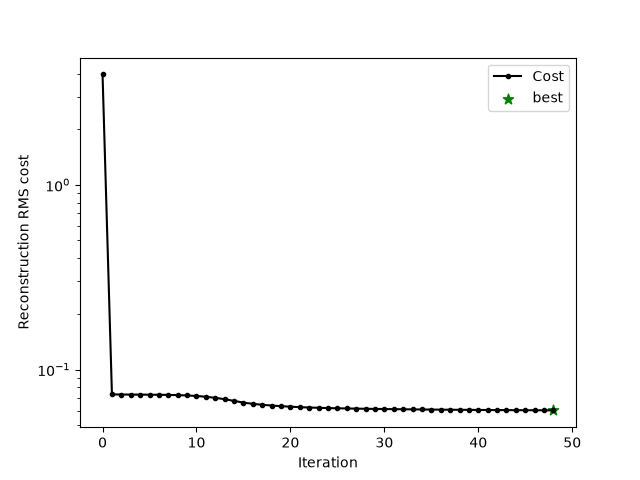

In [37]:

data_gpu = cp.asarray((events_na_free/events_na_free.T.max(axis = 1)).T) # copy data from host memory to vram
# run seqnmf CUDA
result_dict = seqnmf.run_seqnmf_cuda(data_gpu, seqnmf_algo_params, **nmf_misc_kwargs)

# get results from last iteration
W_GPU = result_dict["W_cuda"].get() # W has shape (L, N_channels, K) | copy from GPU to host memory
H_GPU = result_dict["H_cuda"].get() # H has shape (K, N_amples) | copy from GPU to host memory
# cost_history has shape (n_iters,);
# cost[0] is the cost of initial randomization.
# cost[1] is the cost after 1st randomization. ...
cost_history = result_dict["cost"]
# number of last iteration; if stopped early due to convergence, last_iter < n_iter
last_iter = result_dict["last_iter"]
# the iteration# with lowest cost
best_iter = result_dict["best_iter"]
best_W = result_dict["best_W_cuda"].get()
best_H = result_dict["best_H_cuda"].get()

plt.figure()
plt.plot(np.arange(last_iter+1), cost_history[:last_iter+1], color="k", marker=".", label="Cost")
plt.scatter([best_iter], [cost_history[best_iter]], color="g", marker="*", s=60, alpha=1, label="best")
plt.xlabel("Iteration")
plt.ylabel("Reconstruction RMS cost")
plt.legend()
plt.yscale("log")
plt.show()

In [ ]:
# Interface difference: seqnmf_cuda W is LxNxK, instead of NxKxL; to leverage column-major ordering in Python

W_conv = W_GPU.reshape(W_GPU.shape[1],W_GPU.shape[2], W_GPU.shape[0] )
plot_cpu(W_conv, H_GPU)

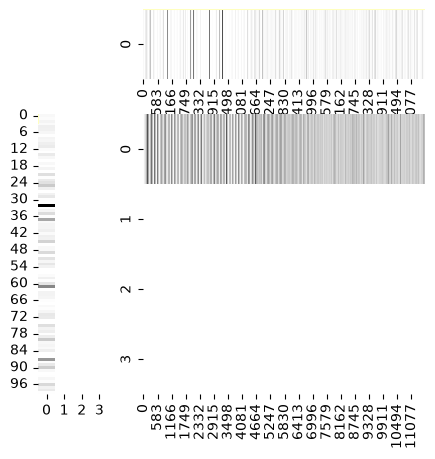

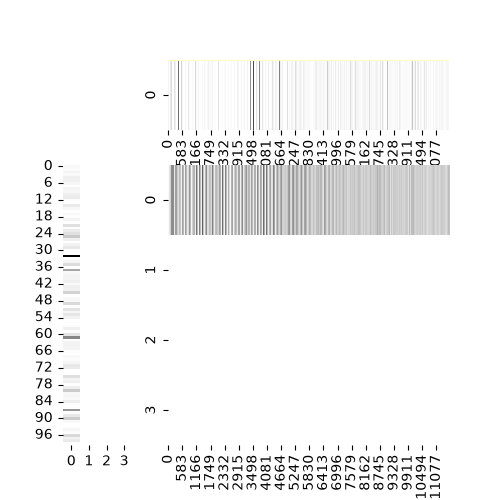

In [46]:
%matplotlib widget
# this doesnt seem to be working right. 
plot(W, H)

In [9]:
W.shape

(50, 927, 20)

In [10]:
H.shape

(20, 11645)

In [11]:
W.T.shape

(20, 927, 50)

In [47]:
seqnmf.reconstruct(W_GPU, H_GPU)

ValueError: non-scalar numpy.ndarray cannot be used for fill

In [50]:
L

50

In [49]:
L, N, K = W_GPU.shape # LxNxK
T = H_GPU.shape[1] # KxT

H_cuda = cp.pad(H_GPU, ((0,0),(L,L)), mode="constant", constant_values=0)

ValueError: non-scalar numpy.ndarray cannot be used for fill

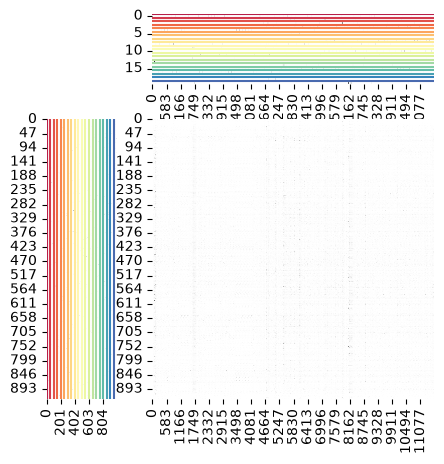

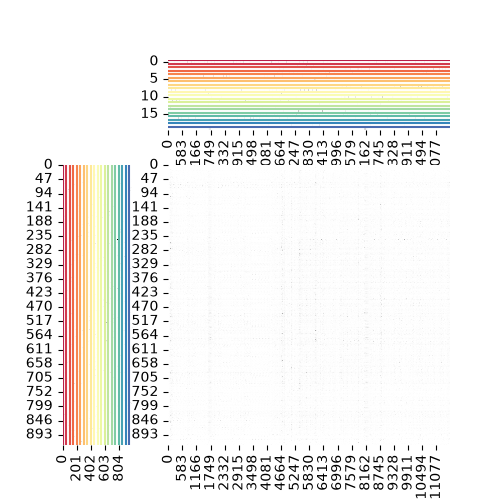

In [45]:
from seqnmf import seqnmf as seqnmf_cpu
from seqnmf import plot as plot_cpu
from seqnmf import example_data

# [W, H, cost, loadings, power] = seqnmf_cpu(events_na_free.T, K=20, L=100, Lambda=0.001, plot_it=True)

plot_cpu(W_conv, H_GPU)

In [ ]:
# [W, H, cost, loadings, power] = seqnmf_cpu(events_na_free.T, K=20, L=100, Lambda=0.001, plot_it=False)

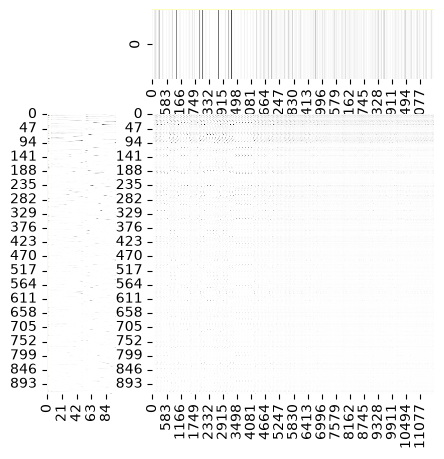

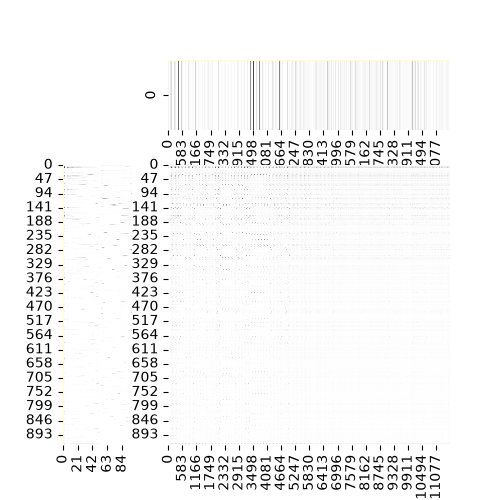

In [51]:
plot_cpu(W, H)